<a href="https://colab.research.google.com/github/Andresmaciasppp/Tarea-An-lisis-N-merico/blob/main/Tarea_N%C3%BAmerico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# UIS - Análisis Númerico

## Fenómeno de Runge, inestabilidad e interpolación a trozos

### Cristian Andres Castellanos Macias - 2220965

Vamos a trabajar con la función de Runge

$$
f(x)=\frac{1}{1+\alpha x^2}.
$$

Objtivo de estudio:

1. **Validar el fenómeno de no convergencia** de la interpolación global de Lagrange con nodos equidistantes.
2. **Validar la inestabilidad** cuando se perturban los datos nodales.
3. **Conectar lo anterior con la interpolación a trozos**, usando la misma función.

De ahora en adelante la letra $n$ representa el **número de nodos**.  
Por tanto, el polinomio interpolante global tiene grado a lo sumo $n-1$.

---

La interpolación global de Lagrange construye un único polinomio $P_{n-1}$ que satisface

$$
P_{n-1}(x_i)=f(x_i), \qquad i=0,1,\dots,n-1.
$$

Cuando los nodos se toman equiespaciados y el valor de 𝑛 aumenta, puede suceder que el polinomio interpolante presente oscilaciones muy grandes cerca de los extremos del intervalo.
A este comportamiento se le denomina fenómeno de Runge.

Por otra parte, si en lugar de interpolar los valores exactos
𝑓(𝑥𝑖) se utilizan valores perturbados para realizar la interpolación, entonces

$$
f(x_i)+\delta y_i,
$$

el nuevo interpolante puede cambiar mucho, incluso si las perturbaciones $\delta y_i$ son pequeñas.  
Esto muestra la **inestabilidad** del método global.

Para evitar esos problemas, se puede usar **interpolación a trozos**, donde en lugar de un polinomio global de grado alto se usan polinomios de grado bajo en subintervalos pequeños.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True


def f_runge(x, alpha=1.0):
    x = np.asarray(x, dtype=float)
    return 1.0 / (1.0 + alpha*x**2)


def nodos_equidistantes(a, b, n):
    if n < 2:
        raise ValueError("n debe ser al menos 2.")
    return np.linspace(a, b, n)


def nodos_chebyshev(a, b, n):
    if n < 2:
        raise ValueError("n debe ser al menos 2.")
    k = np.arange(n)
    x = np.cos((2*k + 1) * np.pi / (2*n))   # en [-1,1]
    # ordenamos para trabajar de izquierda a derecha
    return np.sort(0.5*(a+b) + 0.5*(b-a)*x)


def pesos_barycentric(xn):
    xn = np.asarray(xn, dtype=float)
    n = len(xn)
    w = np.ones(n)

    for i in range(n):
        prod = 1.0
        xi = xn[i]
        for j in range(n):
            if j != i:
                prod *= (xi - xn[j])
        w[i] = 1.0 / prod

    return w


def barycentric_eval(xn, yn, w, x):
    xn = np.asarray(xn, dtype=float)
    yn = np.asarray(yn, dtype=float)
    w  = np.asarray(w, dtype=float)
    x  = np.asarray(x, dtype=float)

    escalar = (x.ndim == 0)
    if escalar:
        x = x[None]

    diff = x[:, None] - xn[None, :]
    out = np.empty(len(x))

    hit = np.isclose(diff, 0.0)
    has_hit = hit.any(axis=1)

    if np.any(has_hit):
        idx = np.argmax(hit[has_hit], axis=1)
        out[has_hit] = yn[idx]

    mask = ~has_hit
    if np.any(mask):
        dm = diff[mask]
        num = np.sum((w*yn)/dm, axis=1)
        den = np.sum(w/dm, axis=1)
        out[mask] = num / den

    return out[0] if escalar else out


def datos_interpolacion_global(a, b, n, alpha=1.0, nodos="equi", xg=None):
    if xg is None:
        xg = np.linspace(a, b, 6000)

    yg = f_runge(xg, alpha=alpha)

    if nodos == "equi":
        xn = nodos_equidistantes(a, b, n)
    elif nodos == "cheb":
        xn = nodos_chebyshev(a, b, n)
    else:
        raise ValueError("nodos debe ser 'equi' o 'cheb'.")

    yn = f_runge(xn, alpha=alpha)
    w = pesos_barycentric(xn)
    pg = barycentric_eval(xn, yn, w, xg)

    return xg, yg, xn, yn, pg


def plot_interp(a, b, n, alpha=1.0, nodos="equi", zoom=None, titulo=None):
    xg, yg, xn, yn, pg = datos_interpolacion_global(a, b, n, alpha, nodos)

    plt.figure(figsize=(10, 5))
    plt.plot(xg, yg, linewidth=2.2, label="f(x)")
    plt.plot(xg, pg, "--", linewidth=2.0, label=f"Lagrange global (n={n}, {nodos})")
    plt.scatter(xn, yn, s=28, color="gray", edgecolor="black", linewidth=0.4, label="nodos")

    if zoom is not None:
        plt.xlim(zoom)

    plt.title(titulo if titulo is not None else "Interpolación global de Lagrange")
    plt.legend(loc="best")
    plt.grid(True, alpha=0.3)
    plt.show()


def error_infinito_global(a, b, n, alpha=1.0, nodos="equi"):
    xg = np.linspace(a, b, 30000)
    yg = f_runge(xg, alpha=alpha)
    _, _, xn, yn, pg = datos_interpolacion_global(a, b, n, alpha, nodos, xg)
    return np.max(np.abs(yg - pg))

## 1. Validación del fenómeno de no convergencia

Primero se estudia la función

$$
f(x)=\frac{1}{1+x^2}
$$

en el intervalo $[-5,5]$, usando nodos equidistantes.

El propósito es analizar qué sucede cuando se incrementa la cantidad de nodos.
Si la interpolación global tuviera un buen comportamiento, sería natural esperar que, al aumentar ($n$), el polinomio se aproximara cada vez más a la función original.

No obstante, en el ejemplo de Runge ocurre lo contrario en las cercanías de los extremos del intervalo: comienzan a manifestarse oscilaciones que se vuelven cada vez más pronunciadas.


En las siguientes gráficas usamos $n=9$, $n=15$ y $n=21$ nodos.

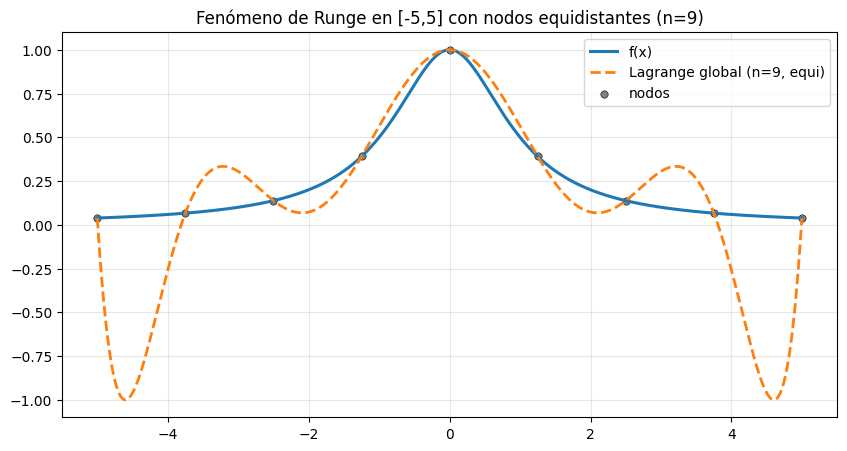

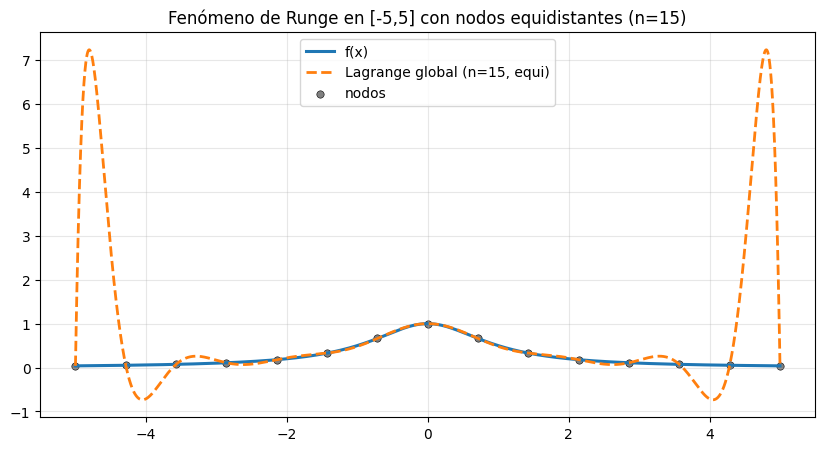

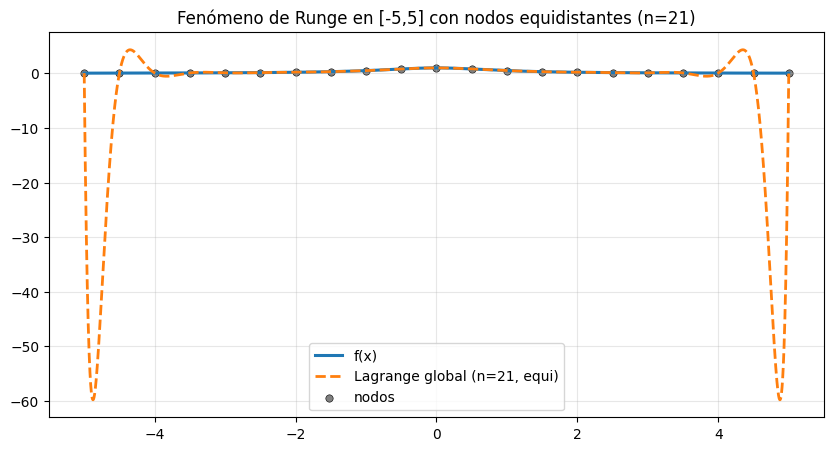

In [ ]:
a, b = -5, 5
alpha = 1.0

for n in [9, 15, 21]:
    plot_interp(
        a, b, n,
        alpha=alpha,
        nodos="equi",
        titulo=f"Fenómeno de Runge en [-5,5] con nodos equidistantes (n={n})"
    )

En la gráfica general ya se puede apreciar que el polinomio interpolante global comienza a distorsionarse en los extremos del intervalo.
Para analizarlo con mayor detalle, realizamos ampliaciones de la gráfica con el fin de observar con más claridad la oscilación en las cercanías de $(x=5)$ y $(x=-5)$.

Esto resulta relevante porque el fenómeno de Runge no implica que el polinomio falle en todo el intervalo. Con frecuencia, en la zona central la aproximación puede verse bastante adecuada, mientras que en los extremos la calidad de la aproximación se deteriora considerablemente.


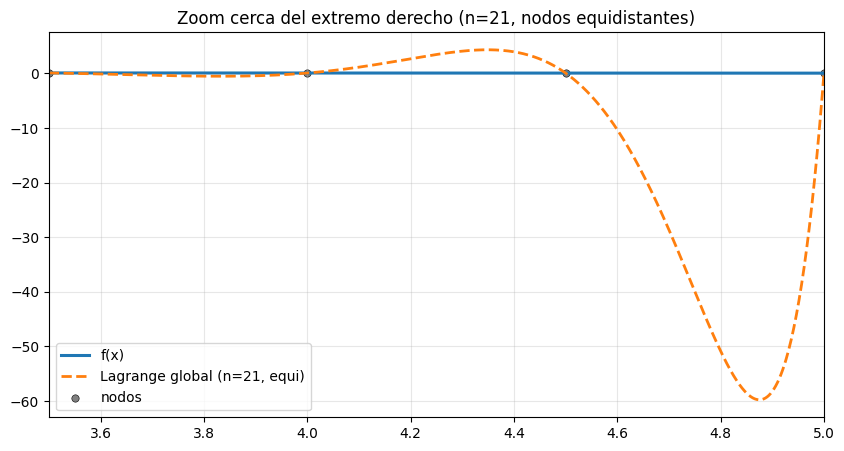

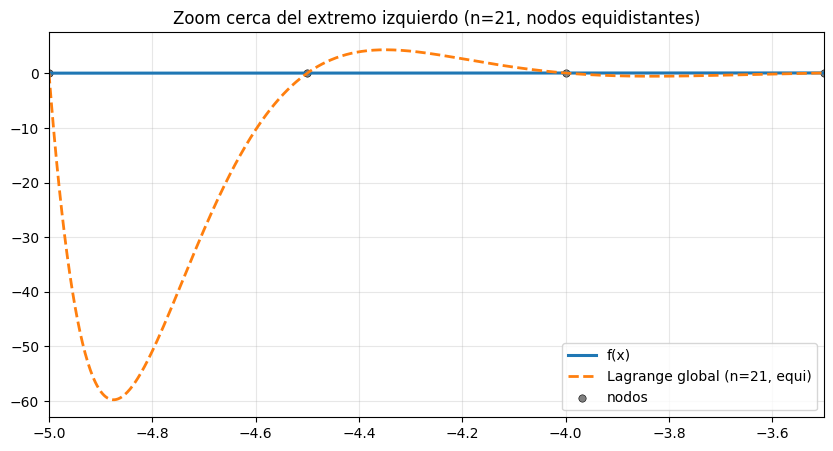

In [ ]:
plot_interp(
    -5, 5, 21,
    alpha=1.0,
    nodos="equi",
    zoom=(3.5, 5.0),
    titulo="Zoom cerca del extremo derecho (n=21, nodos equidistantes)"
)

plot_interp(
    -5, 5, 21,
    alpha=1.0,
    nodos="equi",
    zoom=(-5.0, -3.5),
    titulo="Zoom cerca del extremo izquierdo (n=21, nodos equidistantes)"
)

Para que el fenómeno se vea todavía más fuerte, usamos la versión clásica del ejemplo de Runge:

$$
f(x)=\frac{1}{1+25x^2},
\qquad x\in[-1,1].
$$

Aquí las oscilaciones con nodos equidistantes son todavía más evidentes.  
De nuevo, el mensaje no es que la interpolación de Lagrange sea "mala" en sí misma, sino que la combinación

- polinomio global de grado alto
- nodos equidistantes

se puede producir un comportamiento muy inestable.

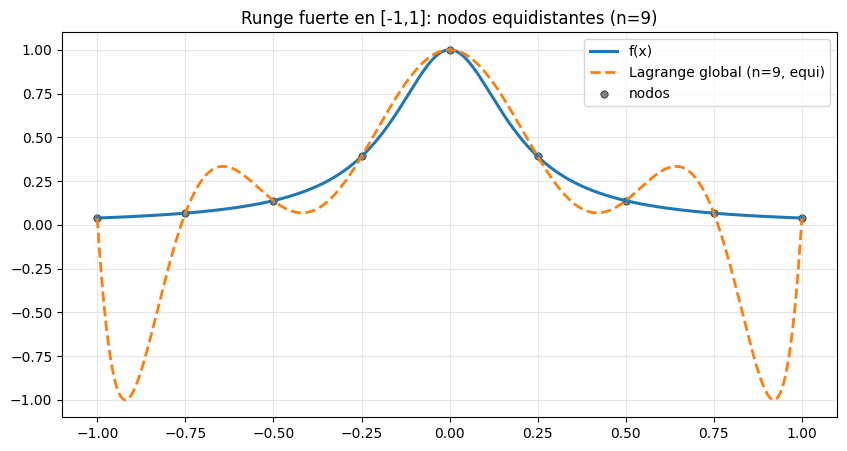

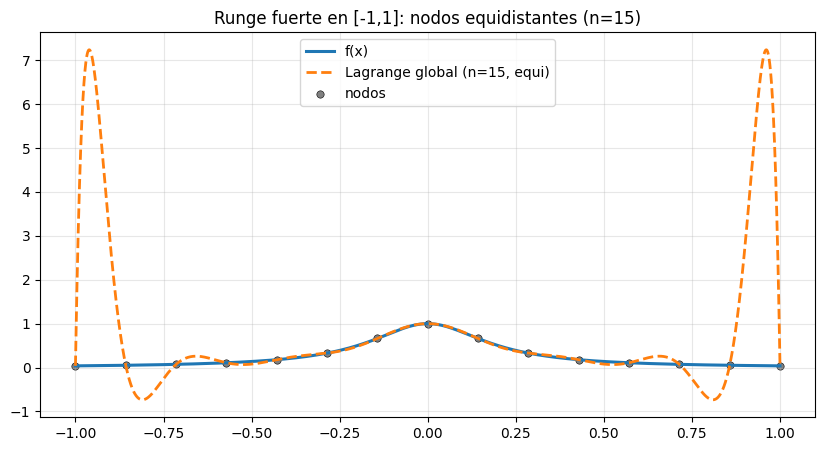

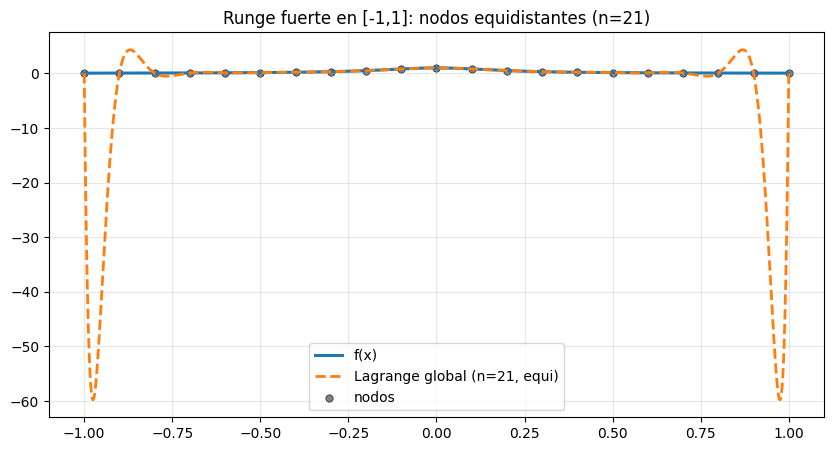

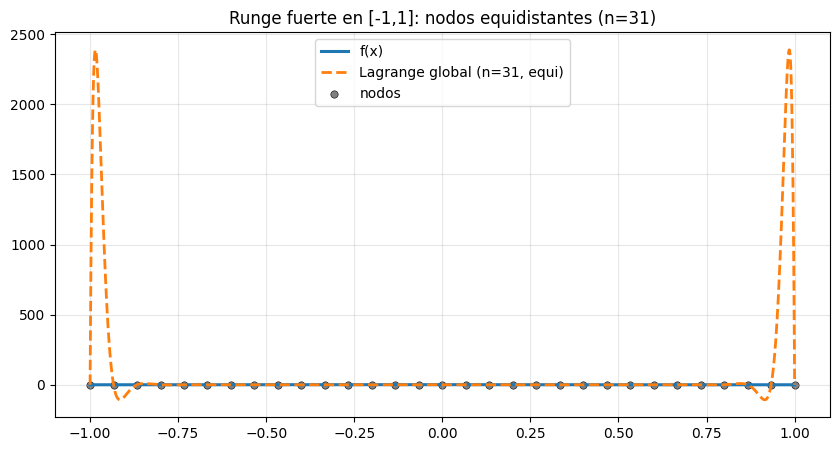

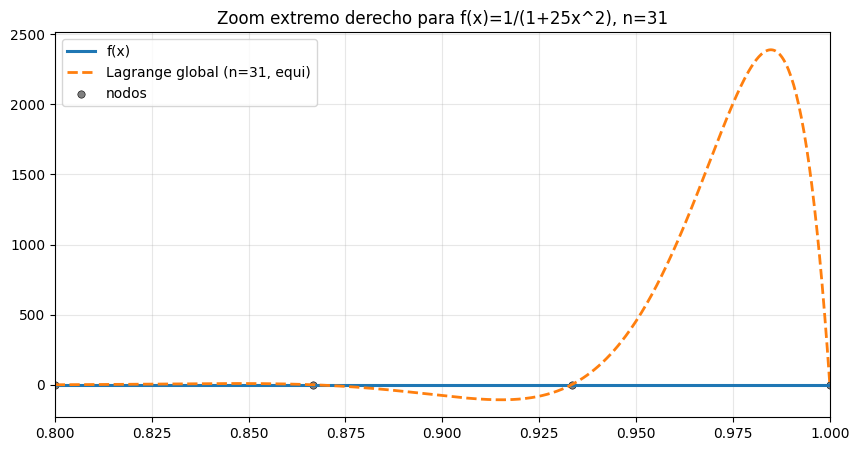

In [ ]:
a, b = -1, 1
alpha = 25.0

for n in [9, 15, 21, 31]:
    plot_interp(
        a, b, n,
        alpha=alpha,
        nodos="equi",
        titulo=f"Runge fuerte en [-1,1]: nodos equidistantes (n={n})"
    )

plot_interp(
    -1, 1, 31,
    alpha=25.0,
    nodos="equi",
    zoom=(0.8, 1.0),
    titulo="Zoom extremo derecho para f(x)=1/(1+25x^2), n=31"
)

Las gráficas anteriores muestran el fenómeno visualmente, pero conviene medirlo de forma cuantitativa.

Para eso calculamos el error máximo

$$
\|f-P_{n-1}\|_{\infty}
=
\max_{x\in[a,b]} |f(x)-P_{n-1}(x)|.
$$

Además, comparamos dos elecciones de nodos:

- **nodos equidistantes**
- **nodos de Chebyshev**

## ¿Qué son los nodos de Chebyshev?

Los nodos de Chebyshev son puntos especialmente elegidos dentro del intervalo para interpolar mejor comparados con nodos equidistantes.  
En el intervalo $[-1,1]$ suelen escribirse como

$$
x_k=\cos\left(\frac{(2k+1)\pi}{2n}\right),
\qquad k=0,1,\dots,n-1.
$$

Si se quiere trabajar en un intervalo general $[a,b]$, esos nodos se transforman linealmente a dicho intervalo.

Lo más importante es que **no están uniformemente repartidos**: se concentran más cerca de los extremos del intervalo.  
Esto es justamente lo contrario de lo que pasa con nodos equidistantes, donde los extremos quedan más expuestos a las oscilaciones del polinomio interpolante.

## ¿Por qué ayudan?

En la interpolación global de Lagrange, el error puede escribirse de la forma

$$
f(x)-P_{n-1}(x)
=
\frac{f^{(n)}(\xi_x)}{n!}\prod_{i=0}^{n-1}(x-x_i),
$$

para algún $\xi_x$ en el intervalo.

Esta fórmula muestra que el error depende de dos cosas:

1. de la derivada de orden alto de la función;
2. del producto

$$
\prod_{i=0}^{n-1}(x-x_i).
$$

Los nodos de Chebyshev se eligen precisamente para controlar mejor ese producto en todo el intervalo.  
De hecho, entre todas las elecciones posibles de nodos, los de Chebyshev minimizan en cierto sentido el tamaño máximo de ese término, y por eso reducen la oscilación del interpolante.

## ¿Por qué en este caso el error disminuye cuando aumentan los nodos?

En este ejemplo, al aumentar $n$ estamos usando más información de la función y, además, los nodos de Chebyshev están ubicados de manera favorable.  
Eso hace que el interpolante global capture cada vez mejor la forma de la función sin generar las grandes oscilaciones que aparecen con nodos equidistantes.

Por eso, en las gráficas y en la norma infinito se observa que, al crecer $n$, el error con nodos de Chebyshev **sí disminuye**.

Dicho de otra manera:

- Con **nodos equidistantes**, aumentar el número de nodos puede empeorar el comportamiento cerca de los extremos;
- Con **nodos de Chebyshev**, aumentar el número de nodos suele mejorar la aproximación, porque los extremos están mejor controlados.

Así, esta comparación muestra que el problema no es la interpolación polinómica global por sí sola, sino la elección de los nodos.

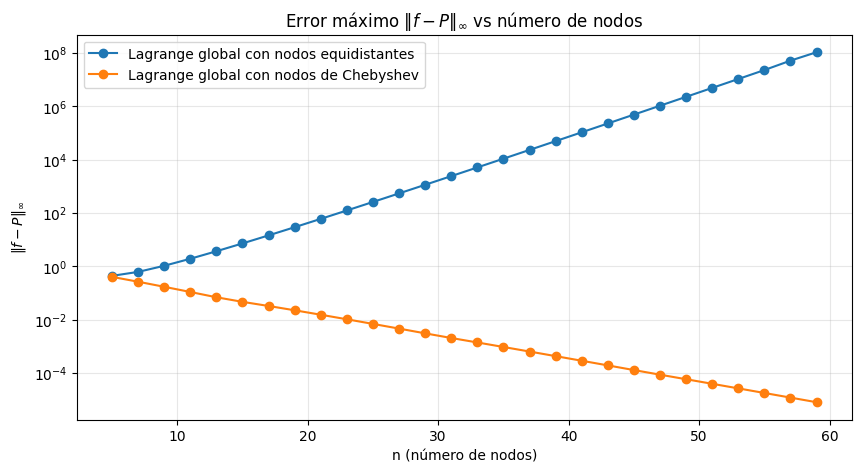

In [ ]:
a, b = -5, 5
alpha = 1.0
nvals = list(range(5, 61, 2))

err_equi = [error_infinito_global(a, b, n, alpha, "equi") for n in nvals]
err_cheb = [error_infinito_global(a, b, n, alpha, "cheb") for n in nvals]

plt.figure(figsize=(10, 5))
plt.semilogy(nvals, err_equi, marker="o", label="Lagrange global con nodos equidistantes")
plt.semilogy(nvals, err_cheb, marker="o", label="Lagrange global con nodos de Chebyshev")
plt.title("Error máximo $\\|f-P\\|_\\infty$ vs número de nodos")
plt.xlabel("n (número de nodos)")
plt.ylabel("$\\|f-P\\|_\\infty$")
plt.grid(True, which="both", alpha=0.3)
plt.legend(loc="best")
plt.show()

A partir de las gráficas y del error máximo, se valida el primer punto de la tarea:

- con **nodos equidistantes**, el error no mejora de manera uniforme al aumentar $n$;
- de hecho, cerca de los extremos aparecen oscilaciones muy grandes;
- en cambio, con **nodos de Chebyshev** el comportamiento mejora notablemente.

Por tanto, en el ejemplo de Runge se observa que la interpolación global de Lagrange con nodos equidistantes puede **no converger uniformemente** al aumentar el número de nodos.

---

## 2. Validación de la inestabilidad

Ahora ya no vamos a comparar $f$ con el interpolante, sino dos interpolantes distintos:

- el interpolante original $P$ construido con los datos exactos,
- el interpolante perturbado $\widetilde{P}$ construido con datos modificados.

Si los valores nodales son

$$
y_i=f(x_i),
$$

y luego los cambiamos por

$$
\widetilde{y}_i = y_i + \delta y_i,
$$

entonces podemos medir la diferencia entre ambos interpolantes mediante

$$
\|\widetilde{P}-P\|_{\infty}.
$$

También nos interesa la razón

$$
\frac{\|\widetilde{P}-P\|_{\infty}}{\|\delta y\|_{\infty}},
$$

que mide cuánto se amplifica la perturbación en el polinomio.

En las celdas siguientes dejamos solo dos valores de perturbación:

$$
\varepsilon = 0.1 \quad \text{y} \quad \varepsilon = 0.2.
$$

In [ ]:
def eval_metodo(xn, yn, xg, metodo="global"):
    xn = np.asarray(xn, dtype=float)
    yn = np.asarray(yn, dtype=float)
    xg = np.asarray(xg, dtype=float)

    if metodo == "global":
        w = pesos_barycentric(xn)
        return barycentric_eval(xn, yn, w, xg)
    elif metodo == "trozos":
        return np.interp(xg, xn, yn)
    else:
        raise ValueError("metodo debe ser 'global' o 'trozos'.")


def construir_delta(n, eps=1e-6, modo="uno", seed=0, eps_vec=None):
    rng = np.random.default_rng(seed)

    if eps_vec is not None:
        delta = np.asarray(eps_vec, dtype=float)
        if len(delta) != n:
            raise ValueError("eps_vec debe tener longitud n.")
        return delta.copy()

    delta = np.zeros(n, dtype=float)

    if modo == "uno":
        delta[n // 2] = eps
    elif modo == "todos":
        delta[:] = eps
    elif modo == "aleatorio":
        delta = eps * rng.choice([-1, 1], size=n)
    elif modo == "algunos":
        idx = rng.choice(n, size=max(1, n//5), replace=False)
        delta[idx] = eps * rng.choice([-1, 1], size=len(idx))
    elif modo == "distinto":
        delta = rng.uniform(-eps, eps, size=n)
    else:
        raise ValueError("modo inválido.")

    return delta


def interp_con_perturbacion(a, b, n, alpha=1.0, eps=1e-6, modo="uno",
                            metodo="global", nodos="equi", seed=0,
                            eps_vec=None, xg=None):
    if xg is None:
        xg = np.linspace(a, b, 6000)

    fg = f_runge(xg, alpha=alpha)

    if nodos == "equi":
        xn = nodos_equidistantes(a, b, n)
    elif nodos == "cheb":
        xn = nodos_chebyshev(a, b, n)
    else:
        raise ValueError("nodos debe ser 'equi' o 'cheb'.")

    yn = f_runge(xn, alpha=alpha)
    delta = construir_delta(n, eps=eps, modo=modo, seed=seed, eps_vec=eps_vec)
    yn2 = yn + delta

    P = eval_metodo(xn, yn, xg, metodo=metodo)
    P2 = eval_metodo(xn, yn2, xg, metodo=metodo)

    return xg, fg, xn, yn, yn2, delta, P, P2


def plot_inestabilidad(a, b, n, alpha, eps, modo="uno", metodo="global",
                       nodos="equi", seed=0, eps_vec=None, zooms=None):
    xg, fg, xn, yn, yn2, delta, P, P2 = interp_con_perturbacion(
        a, b, n, alpha, eps, modo, metodo, nodos, seed, eps_vec
    )

    diff = P2 - P
    diff_abs = np.abs(diff)

    imax = int(np.argmax(diff_abs))
    xmax = float(xg[imax])
    maxdiff = float(diff_abs[imax])
    dy_inf = float(np.max(np.abs(delta)))
    amp = maxdiff / dy_inf if dy_inf != 0 else np.nan

    nombre = "Lagrange global" if metodo == "global" else "lineal a trozos"

    print(f"Método: {nombre}")
    print(f"eps = {eps}")
    print(f"||δy||_inf = {dy_inf:.3e}")
    print(f"max |P~ - P| = {maxdiff:.3e} en x ≈ {xmax:.6f}")
    print(f"Amplificación empírica ≈ {amp:.3e}")

    if zooms is None:
        L = b - a
        zooms = [(a, a + 0.2*L), (b - 0.2*L, b)]

    def dibujar(z0=None, z1=None):
        if z0 is None:
            mask = slice(None)
            titulo = f"{nombre}: comparación completa (modo={modo}, eps={eps})"
            xlim = (a, b)
            xn_plot, yn_plot = xn, yn
        else:
            z0 = max(a, z0)
            z1 = min(b, z1)
            mask = (xg >= z0) & (xg <= z1)
            titulo = f"{nombre}: zoom [{z0:.3f}, {z1:.3f}] (modo={modo}, eps={eps})"
            xlim = (z0, z1)
            m_nodes = (xn >= z0) & (xn <= z1)
            xn_plot, yn_plot = xn[m_nodes], yn[m_nodes]

        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True, constrained_layout=True)

        ax1.plot(xg[mask], fg[mask], color="black", linewidth=2.2, label="f(x)")
        ax1.plot(xg[mask], P[mask], color="tab:blue", linestyle="--", linewidth=2.0, label="Interpolante original")
        ax1.plot(xg[mask], P2[mask], color="tab:red", linestyle=":", linewidth=2.0, label="Interpolante perturbado")
        ax1.scatter(xn_plot, yn_plot, s=28, color="gray", edgecolor="black", linewidth=0.4, label="nodos")
        ax1.grid(True, alpha=0.3)
        ax1.set_title(titulo)
        ax1.legend(loc="best")

        ax2.plot(xg[mask], diff[mask], color="purple", linewidth=2.0, label="$\\widetilde{P}-P$")
        ax2.plot(xg[mask], diff_abs[mask], color="tab:green", linestyle="--", linewidth=2.0, label="$|\\widetilde{P}-P|$")
        ax2.axhline(0, color="gray", linewidth=1)
        ax2.grid(True, alpha=0.3)
        ax2.legend(loc="best")
        ax1.set_xlim(*xlim)
        ax2.set_xlim(*xlim)

        plt.show()

    dibujar()
    for z0, z1 in zooms:
        dibujar(z0, z1)


def barrido_eps(a, b, n, alpha, eps_list, modo="uno", metodo="global",
                nodos="equi", seed=0, zooms=None):
    for eps in eps_list:
        plot_inestabilidad(
            a, b, n, alpha, eps,
            modo=modo,
            metodo=metodo,
            nodos=nodos,
            seed=seed,
            zooms=zooms
        )


def lebesgue_funcion(a, b, n, nodos="equi"):
    if nodos == "equi":
        xn = nodos_equidistantes(a, b, n)
    elif nodos == "cheb":
        xn = nodos_chebyshev(a, b, n)
    else:
        raise ValueError("nodos debe ser 'equi' o 'cheb'.")

    w = pesos_barycentric(xn)
    xg = np.linspace(a, b, 30000)

    with np.errstate(divide="ignore", invalid="ignore"):
        diff = xg[:, None] - xn[None, :]
        den = np.sum(w / diff, axis=1)
        Li = (w / diff) / den[:, None]

    hit = np.isclose(diff, 0.0)
    Li[hit] = 0.0
    lam = np.sum(np.abs(Li), axis=1)
    lam = np.nan_to_num(lam, nan=1.0, posinf=1.0, neginf=1.0)

    return xg, lam, np.max(lam)


def error_infinito_trozos(a, b, n, alpha=1.0):
    xg = np.linspace(a, b, 30000)
    yg = f_runge(xg, alpha=alpha)
    xn = nodos_equidistantes(a, b, n)
    yn = f_runge(xn, alpha=alpha)
    ig = eval_metodo(xn, yn, xg, metodo="trozos")
    return np.max(np.abs(yg - ig))


def plot_global_vs_trozos(a, b, n, alpha=1.0, zoom=None):
    xg = np.linspace(a, b, 6000)
    yg = f_runge(xg, alpha=alpha)
    xn = nodos_equidistantes(a, b, n)
    yn = f_runge(xn, alpha=alpha)

    pg = eval_metodo(xn, yn, xg, metodo="global")
    ig = eval_metodo(xn, yn, xg, metodo="trozos")

    plt.figure(figsize=(10, 5))
    plt.plot(xg, yg, color="gray", linewidth=2.3, label="f(x)")
    plt.plot(xg, pg, color="tab:red", linestyle="--", linewidth=2.0, label="Lagrange global")
    plt.plot(xg, ig, color="tab:blue", linestyle=":", linewidth=2.3, label="Lineal a trozos")
    plt.scatter(xn, yn, s=28, color="gray", edgecolor="black", linewidth=0.4, label="nodos")

    if zoom is not None:
        plt.xlim(zoom)

    plt.title(f"Comparación entre interpolación global y a trozos (n={n})")
    plt.legend(loc="best")
    plt.grid(True, alpha=0.3)
    plt.show()


def comparar_errores_metodos(a, b, nvals, alpha=1.0):
    err_equi = [error_infinito_global(a, b, n, alpha, "equi") for n in nvals]
    err_cheb = [error_infinito_global(a, b, n, alpha, "cheb") for n in nvals]
    err_troz = [error_infinito_trozos(a, b, n, alpha) for n in nvals]

    plt.figure(figsize=(10, 5))
    plt.semilogy(nvals, err_equi, marker="o", label="Lagrange global con nodos equidistantes")
    plt.semilogy(nvals, err_cheb, marker="o", label="Lagrange global con nodos de Chebyshev")
    plt.semilogy(nvals, err_troz, marker="o", label="Interpolación lineal a trozos")
    plt.title("Comparación del error máximo")
    plt.xlabel("n (número de nodos)")
    plt.ylabel("$\\|f-I\\|_\\infty$")
    plt.grid(True, which="both", alpha=0.3)
    plt.legend(loc="best")
    plt.show()

    return err_equi, err_cheb, err_troz


def comparar_sensibilidad_global_trozos(a, b, n, alpha=1.0, eps=0.2, modo="uno", seed=0):
    xg = np.linspace(a, b, 6000)

    xg, fg, xn, yn, yn2, delta, Pg, Pg2 = interp_con_perturbacion(
        a, b, n, alpha, eps, modo,
        metodo="global",
        nodos="equi",
        seed=seed,
        xg=xg
    )

    _, _, _, _, _, _, Ig, Ig2 = interp_con_perturbacion(
        a, b, n, alpha, eps, modo,
        metodo="trozos",
        nodos="equi",
        seed=seed,
        xg=xg
    )

    diffg = np.abs(Pg2 - Pg)
    diffi = np.abs(Ig2 - Ig)

    amp_global = np.max(diffg) / np.max(np.abs(delta))
    amp_trozos = np.max(diffi) / np.max(np.abs(delta))

    print(f"Amplificación global   ≈ {amp_global:.3e}")
    print(f"Amplificación a trozos ≈ {amp_trozos:.3e}")

    fig, axes = plt.subplots(3, 1, figsize=(11, 10), sharex=True, constrained_layout=True)

    axes[0].plot(xg, fg, color="black", linewidth=2.2, label="f(x)")
    axes[0].plot(xg, Pg, color="tab:blue", linestyle="--", linewidth=2.0, label="Global original")
    axes[0].plot(xg, Pg2, color="tab:red", linestyle=":", linewidth=2.0, label="Global perturbado")
    axes[0].scatter(xn, yn, s=25, color="gray", edgecolor="black", linewidth=0.4)
    axes[0].set_title("Interpolación global de Lagrange")
    axes[0].legend(loc="best")
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(xg, fg, color="black", linewidth=2.2, label="f(x)")
    axes[1].plot(xg, Ig, color="tab:blue", linestyle="--", linewidth=2.0, label="A trozos original")
    axes[1].plot(xg, Ig2, color="tab:red", linestyle=":", linewidth=2.0, label="A trozos perturbado")
    axes[1].scatter(xn, yn, s=25, color="gray", edgecolor="black", linewidth=0.4)
    axes[1].set_title("Interpolación lineal a trozos")
    axes[1].legend(loc="best")
    axes[1].grid(True, alpha=0.3)

    axes[2].plot(xg, diffg, color="tab:red", linewidth=2.0, label="$|\\widetilde{P}-P|$ global")
    axes[2].plot(xg, diffi, color="tab:blue", linewidth=2.0, label="$|\\widetilde{I}-I|$ a trozos")
    axes[2].set_title("Comparación de sensibilidad frente a la misma perturbación")
    axes[2].legend(loc="best")
    axes[2].grid(True, alpha=0.3)

    plt.show()

### 2.1. Perturbación en un solo nodo

En esta parte modificamos únicamente un dato nodal:

$$
\widetilde{y}_j = y_j + \varepsilon,
$$

y dejamos los demás iguales.

Esto sirve para ver si una alteración pequeña y localizada en los datos produce un cambio pequeño o grande en el interpolante global.

Método: Lagrange global
eps = 0.1
||δy||_inf = 1.000e-01
max |P~ - P| = 6.146e-01 en x ≈ 4.699950
Amplificación empírica ≈ 6.146e+00


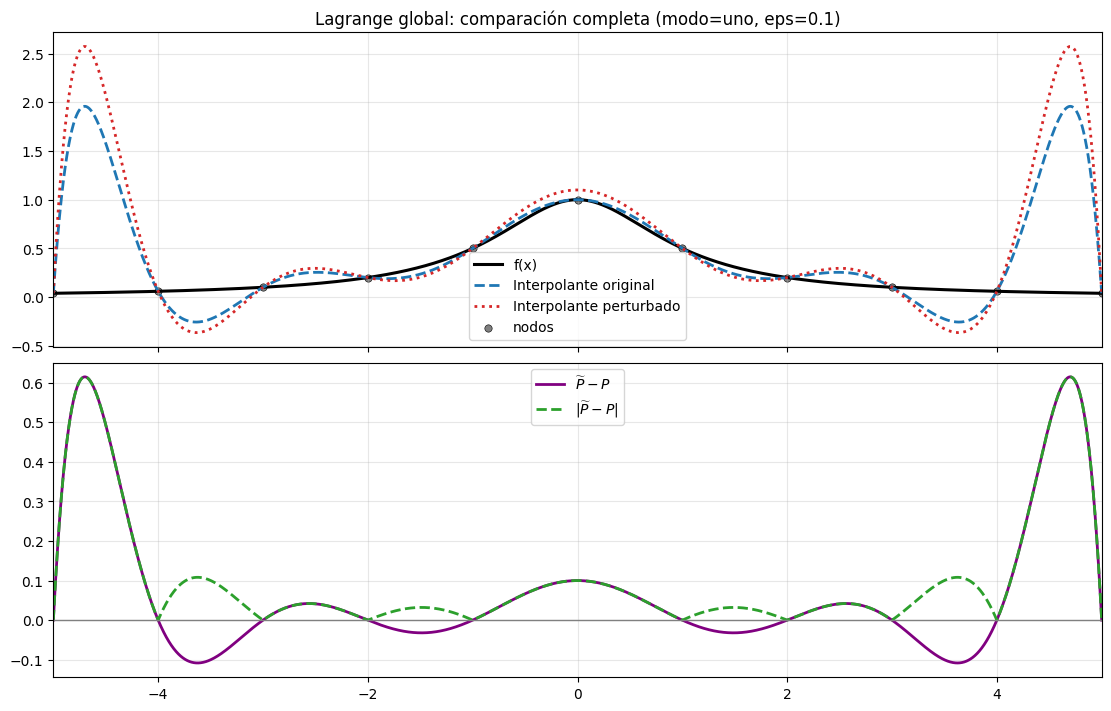

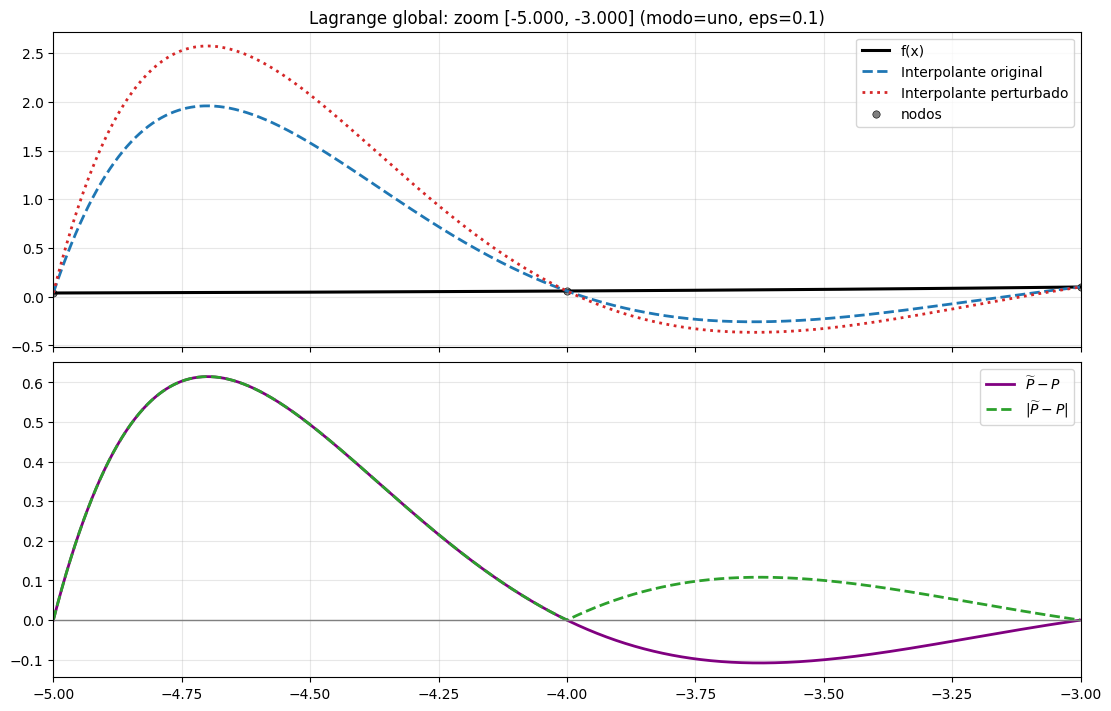

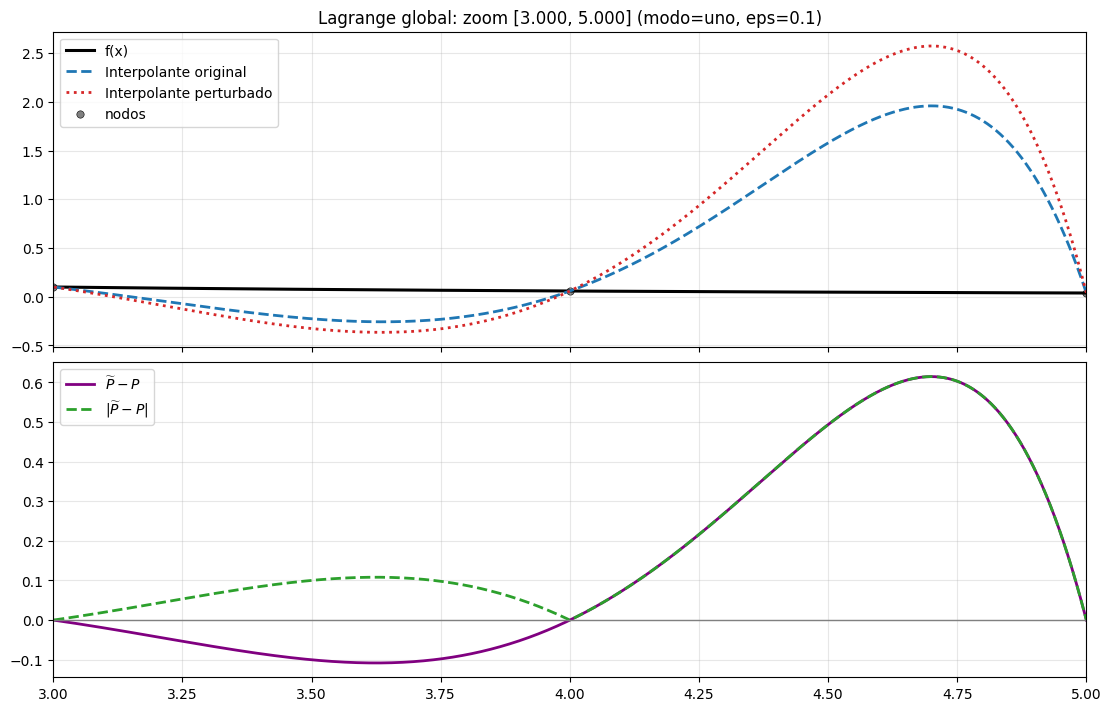

Método: Lagrange global
eps = 0.2
||δy||_inf = 2.000e-01
max |P~ - P| = 1.229e+00 en x ≈ 4.699950
Amplificación empírica ≈ 6.146e+00


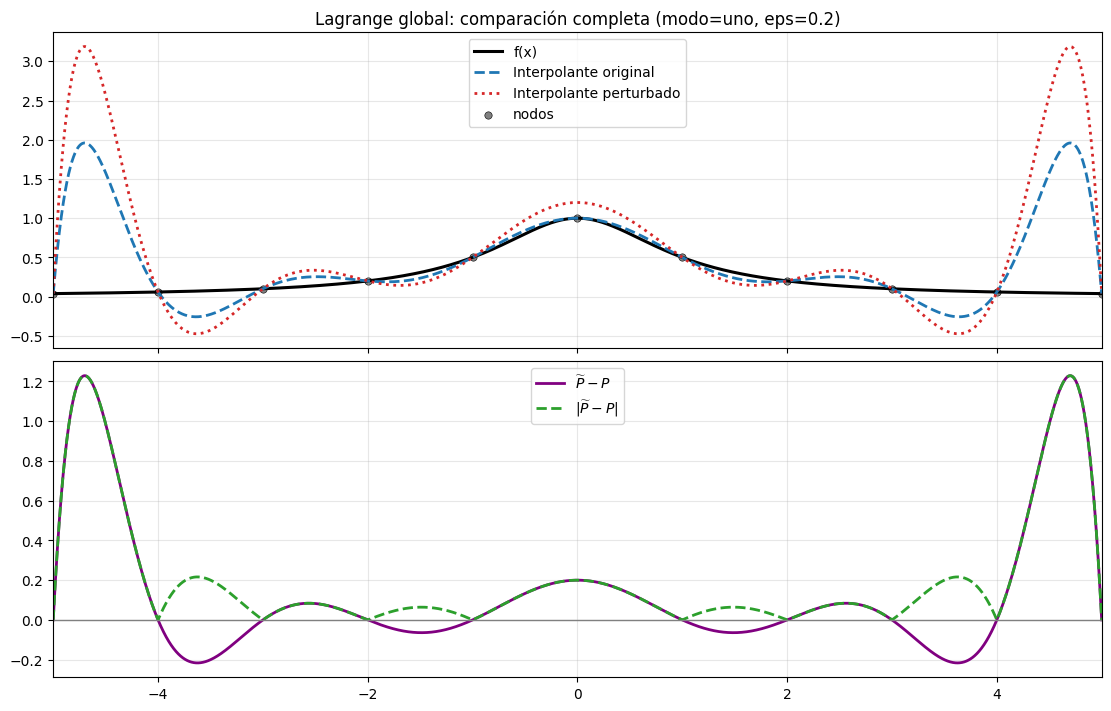

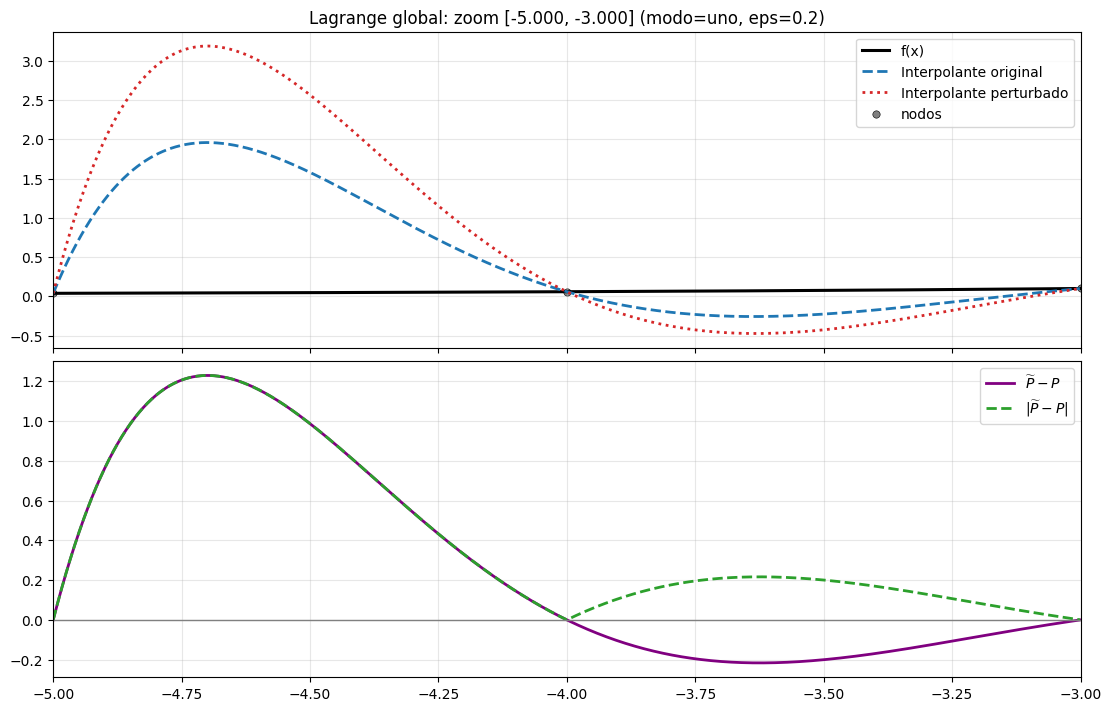

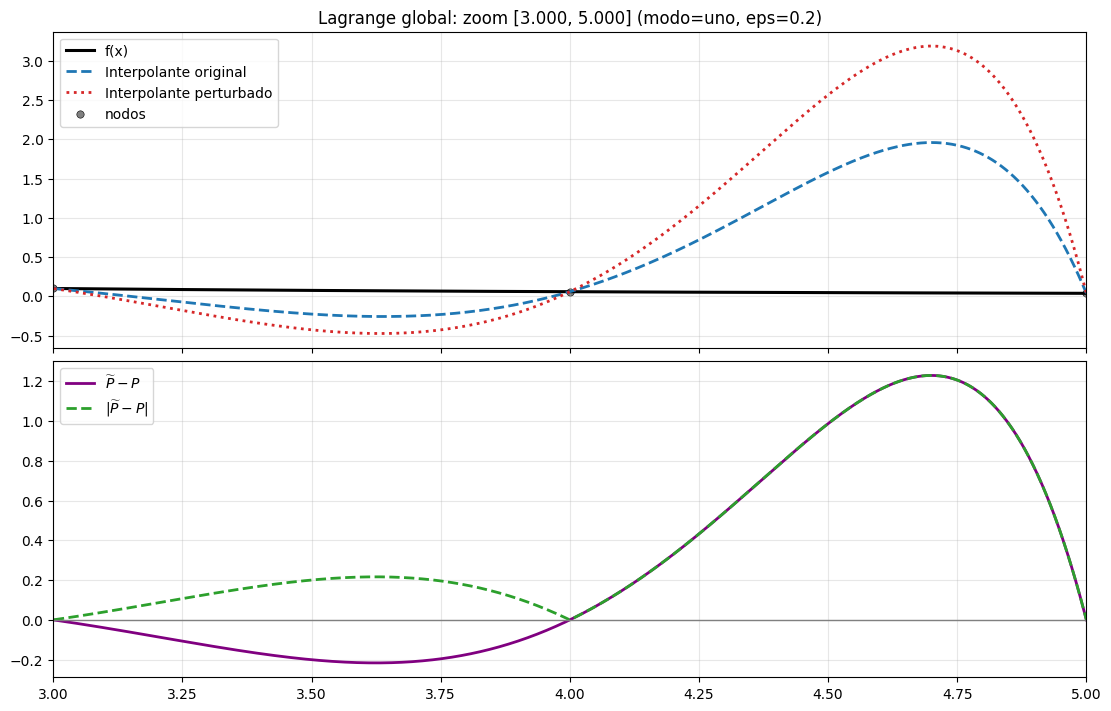

In [ ]:
a, b = -5, 5
alpha = 1.0
n = 11

eps_list = [0.1, 0.2]

barrido_eps(
    a, b, n, alpha,
    eps_list,
    modo="uno",
    metodo="global",
    nodos="equi",
    seed=3
)

### 2.2. Perturbaciones distintas en todos los nodos

Ahora hacemos algo más general: en cada nodo se agrega una perturbación distinta.  
Es decir, en vez de usar un solo $\varepsilon$, usamos un vector de perturbaciones

$$
\delta y = (\delta y_0,\delta y_1,\dots,\delta y_{n-1}),
$$

con valores diferentes en cada componente.

Esto es más realista, porque en la práctica los errores de medición o redondeo no suelen ser idénticos en todos los nodos.

Método: Lagrange global
eps = 0.1
||δy||_inf = 9.984e-02
max |P~ - P| = 2.978e-01 en x ≈ -4.688281
Amplificación empírica ≈ 2.982e+00


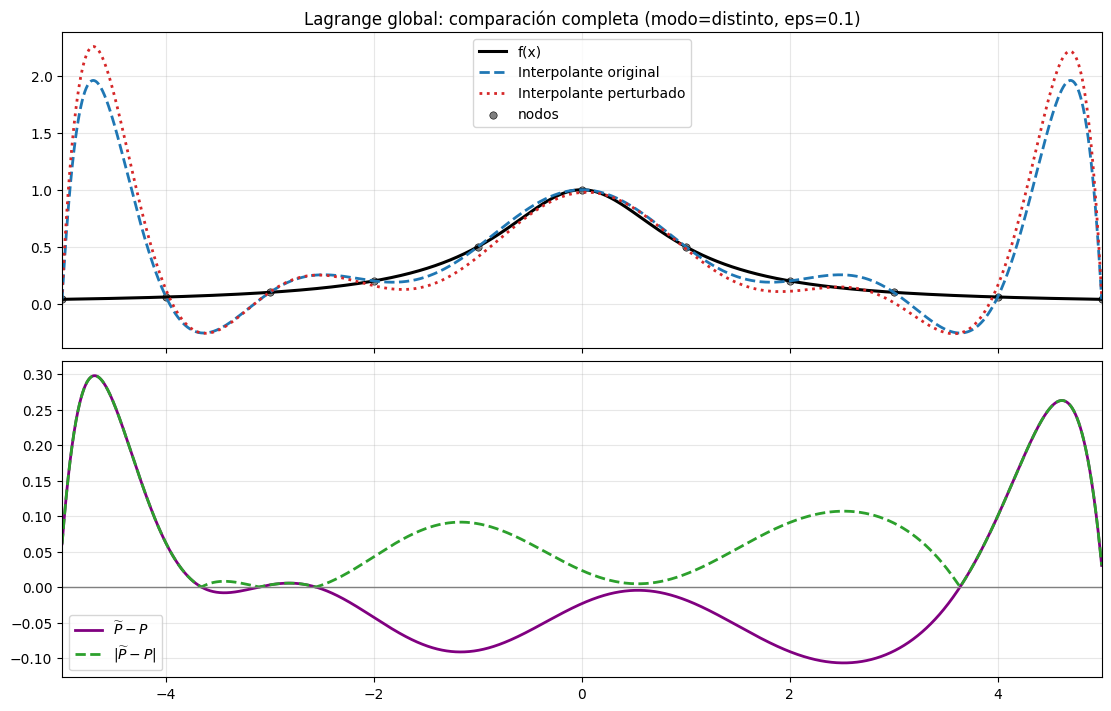

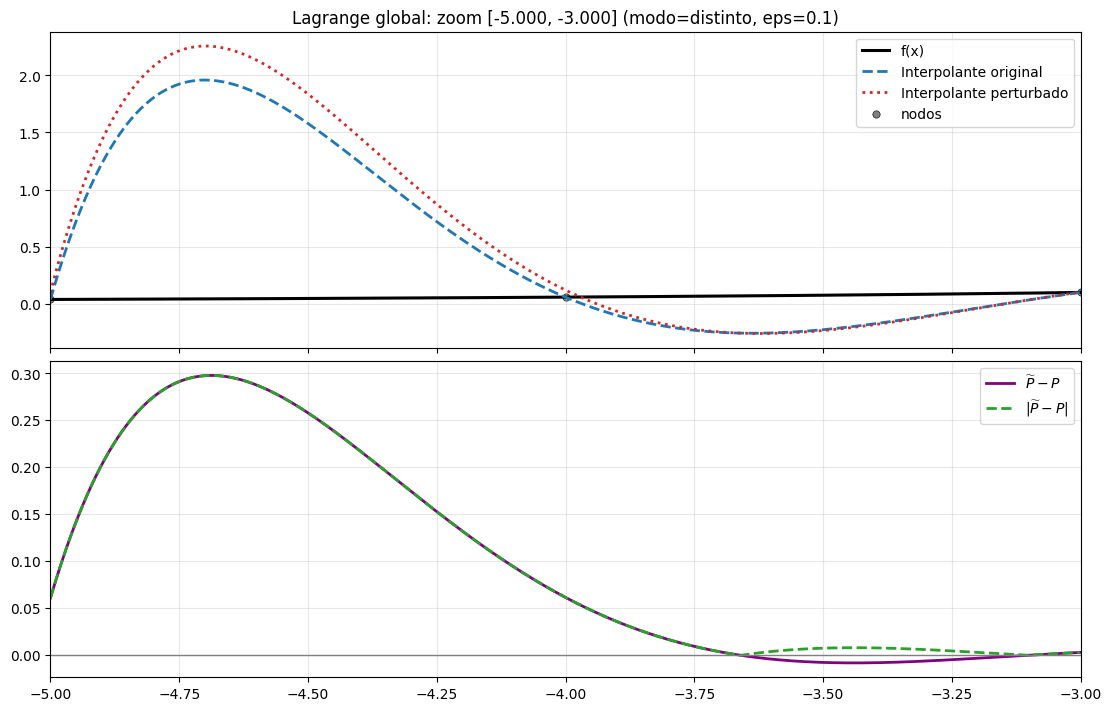

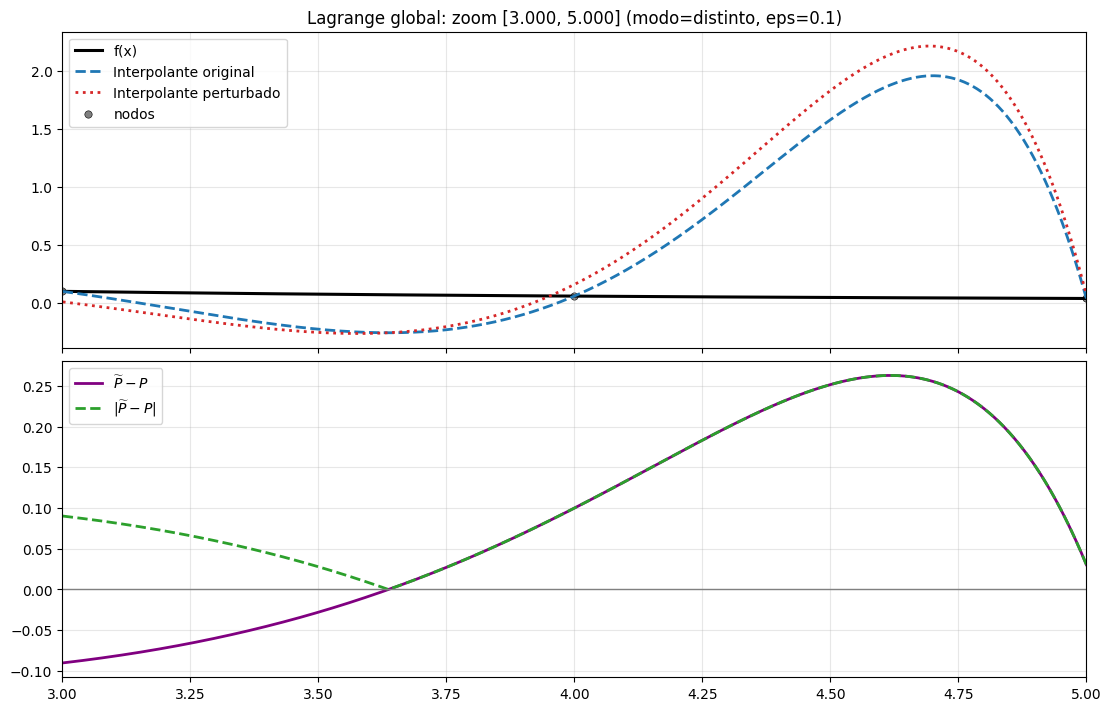

Método: Lagrange global
eps = 0.2
||δy||_inf = 1.997e-01
max |P~ - P| = 5.955e-01 en x ≈ -4.688281
Amplificación empírica ≈ 2.982e+00


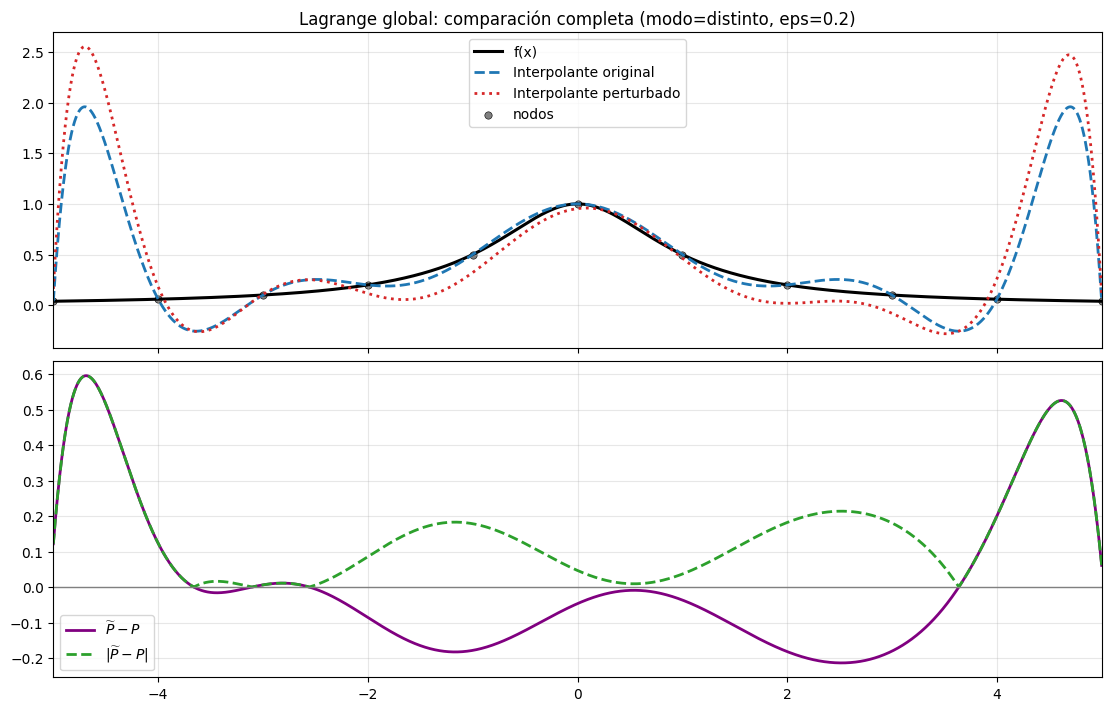

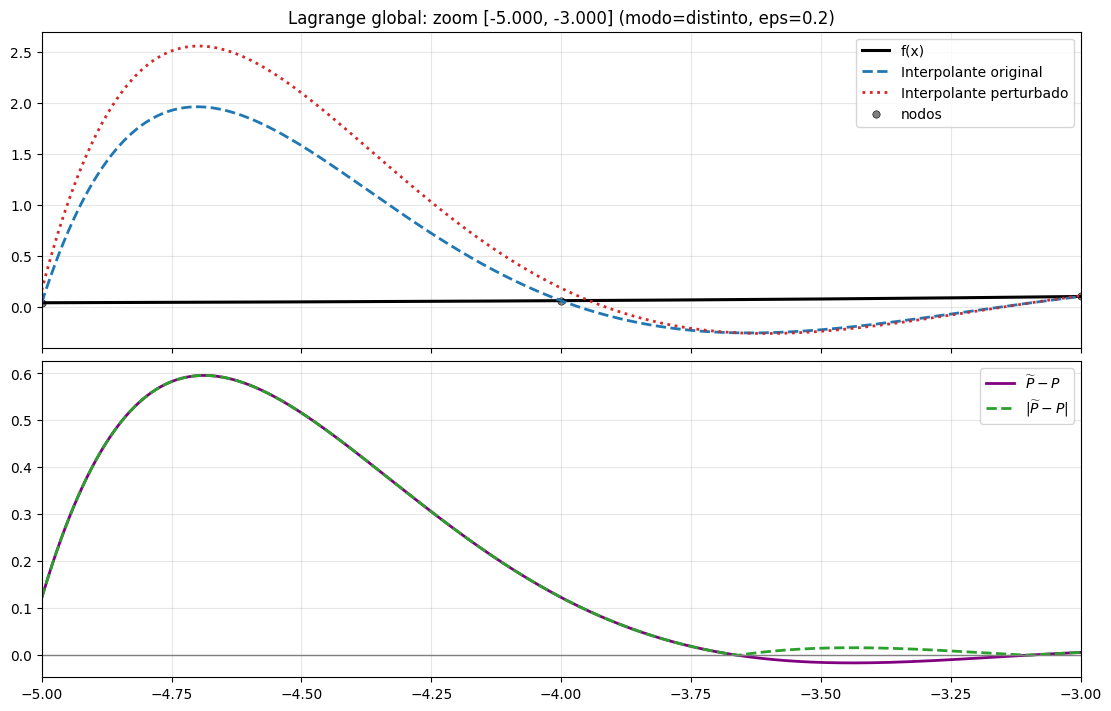

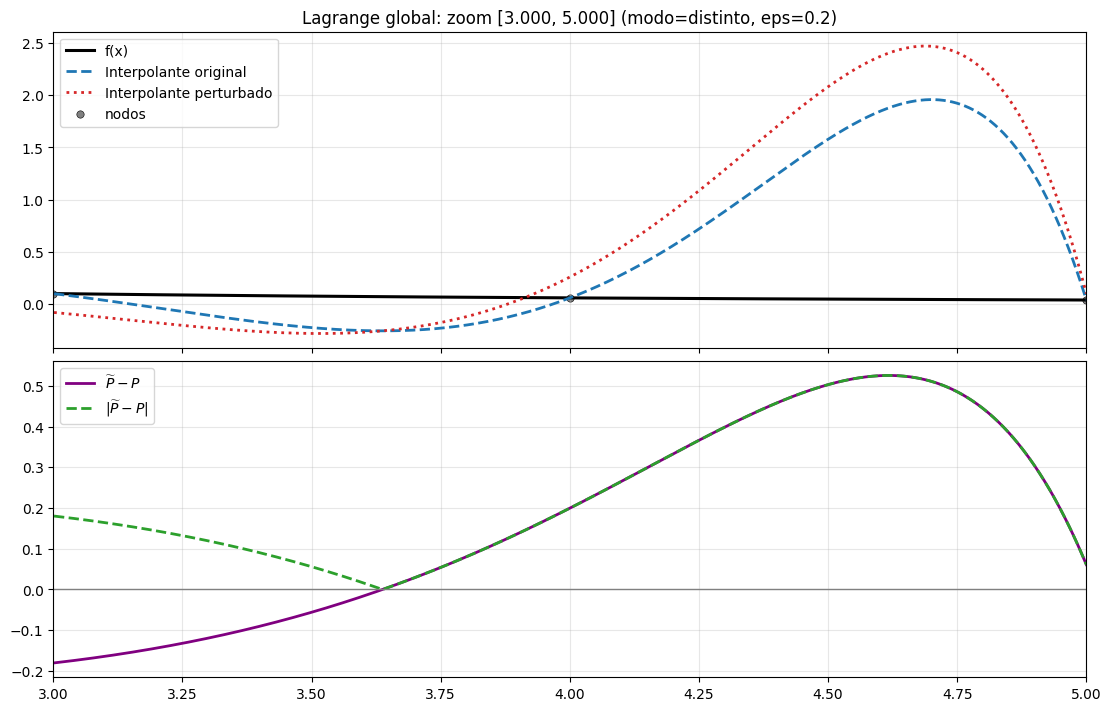

In [ ]:
a, b = -5, 5
alpha = 1.0
n = 11

eps_list = [0.1, 0.2]

barrido_eps(
    a, b, n, alpha,
    eps_list,
    modo="distinto",
    metodo="global",
    nodos="equi",
    seed=5
)

Con las celdas anteriores se valida el segundo punto de la tarea:

- pequeñas perturbaciones en los valores nodales producen cambios visibles en el interpolante global;
- ese cambio se amplifica, sobre todo cerca de los extremos del intervalo.

En otras palabras, el problema no es solo de aproximación, sino también de **estabilidad numérica**.

---

## 3. Interpolación a trozos y conexión con los puntos 1 y 2

Para responder el tercer punto, usamos la misma función

$$
f(x)=\frac{1}{1+x^2}
$$

en el intervalo $[-5,5]$, pero ahora no construiremos un polinomio global de grado alto.  
En su lugar, dividimos el intervalo en subintervalos y en cada trozo usamos un polinomio de grado bajo.

Aquí vamos a usar la versión más simple: **interpolación lineal a trozos**.

Si los nodos son

$$
x_0 < x_1 < \cdots < x_{n-1},
$$

entonces, en cada subintervalo $[x_i,x_{i+1}]$, definimos

$$
I_hf(x)
=
f(x_i)\frac{x_{i+1}-x}{x_{i+1}-x_i}
+
f(x_{i+1})\frac{x-x_i}{x_{i+1}-x_i}.
$$

Este método tiene una idea clave:

- en vez de usar un polinomio global de grado grande,
- usamos muchos polinomios locales de grado $1$.

Eso reduce las oscilaciones globales y además hace que las perturbaciones se propaguen mucho menos.


===== Comparación con n=11 nodos =====
Error global equidistante = 1.915659e+00
Error lineal a trozos     = 6.744224e-02


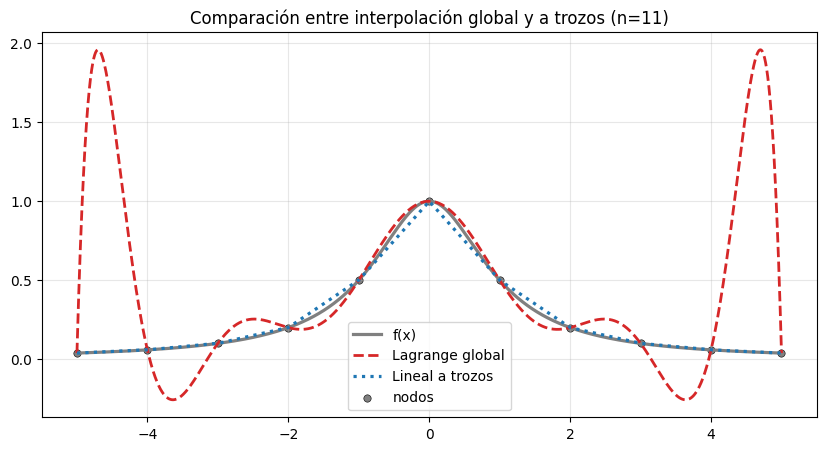


===== Comparación con n=21 nodos =====
Error global equidistante = 5.982231e+01
Error lineal a trozos     = 4.183445e-02


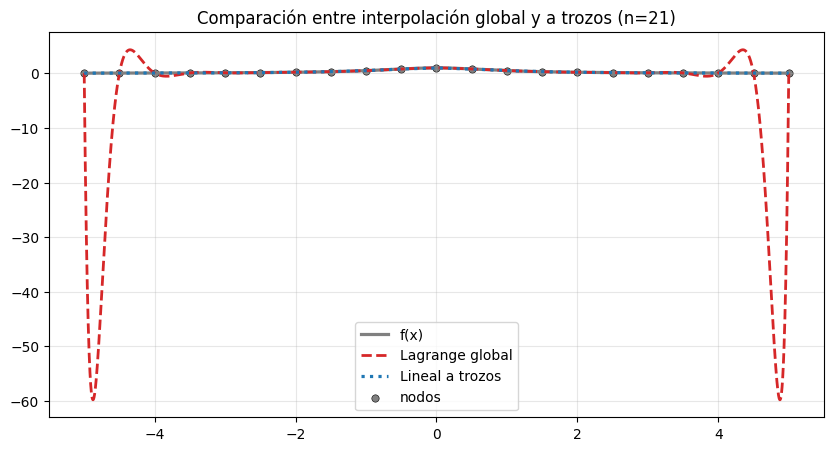


===== Zoom cerca del extremo derecho =====


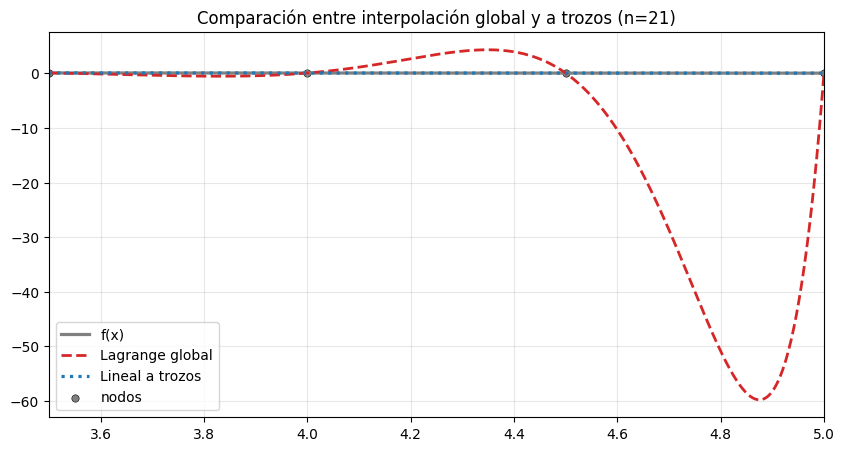

In [ ]:
a, b = -5, 5
alpha = 1.0

for n in [11, 21]:
    print(f"\n===== Comparación con n={n} nodos =====")
    eg = error_infinito_global(a, b, n, alpha, "equi")
    et = error_infinito_trozos(a, b, n, alpha)
    print(f"Error global equidistante = {eg:.6e}")
    print(f"Error lineal a trozos     = {et:.6e}")

    plot_global_vs_trozos(a, b, n, alpha=alpha)

print("\n===== Zoom cerca del extremo derecho =====")
plot_global_vs_trozos(-5, 5, 21, alpha=1.0, zoom=(3.5, 5.0))

La comparación anterior muestra algo muy importante:

- la interpolación global con nodos equidistantes produce oscilaciones grandes;
- la interpolación lineal a trozos no presenta ese comportamiento extremo;
- aunque la interpolación a trozos no es tan suave como un polinomio global, sí controla mucho mejor el error.

Esto conecta directamente con el punto 1:  
la interpolación a trozos aparece como una forma natural de evitar el fenómeno de Runge.

Además, para interpolación lineal a trozos existe una cota clásica del error:

$$
|f(x)-I_hf(x)| \leq \frac{h^2}{8}\max_{[a,b]} |f''(x)|,
$$

donde $h$ es la longitud máxima de los subintervalos.  
Esto muestra que, al refinar la partición, el error sí tiende a disminuir.

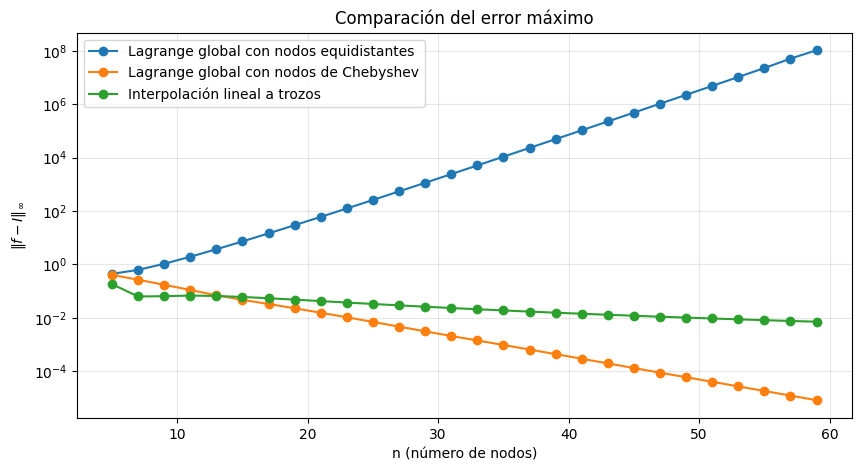

In [ ]:
a, b = -5, 5
alpha = 1.0
nvals = list(range(5, 61, 2))

err_equi, err_cheb, err_troz = comparar_errores_metodos(a, b, nvals, alpha=alpha)

## Conexión entre inestabilidad global e interpolación a trozos

Ahora repetimos la idea del punto 2, pero comparando dos métodos con la **misma perturbación en los datos**:

- Interpolación global de Lagrange.
- Interpolación lineal a trozos.

La expectativa es la siguiente:

- En la interpolación global, una perturbación en un nodo afecta a todo el polinomio.
- En la interpolación a trozos, el efecto es mucho más local.

De hecho, en interpolación lineal a trozos las funciones base son locales y no negativas, por lo que la amplificación del error es mucho más controlada.  
Numéricamente se observa que esa amplificación queda cercana a $1$.

===== Misma perturbación en un solo nodo =====
Amplificación global   ≈ 6.146e+00
Amplificación a trozos ≈ 9.992e-01


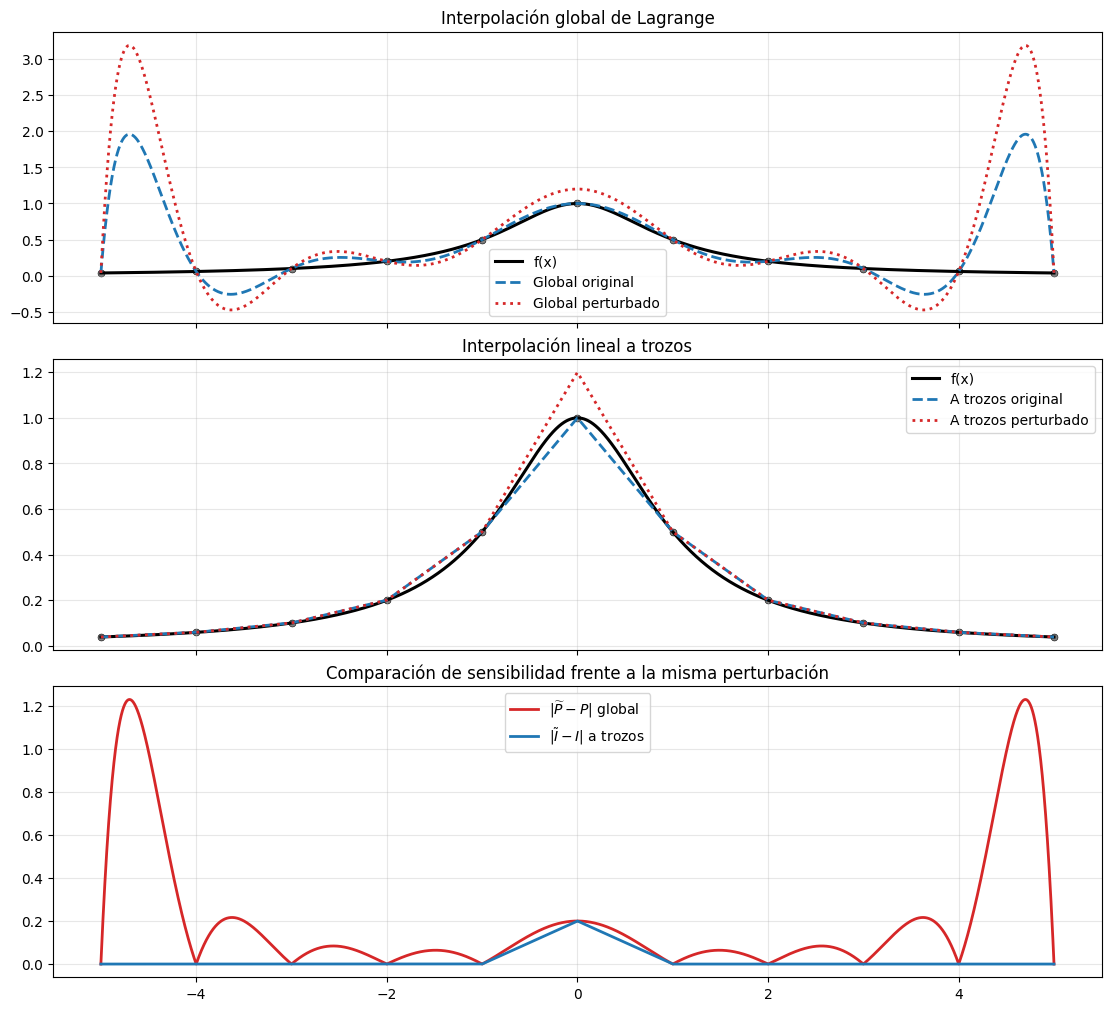


===== Perturbaciones distintas en todos los nodos =====
Amplificación global   ≈ 2.982e+00
Amplificación a trozos ≈ 9.997e-01


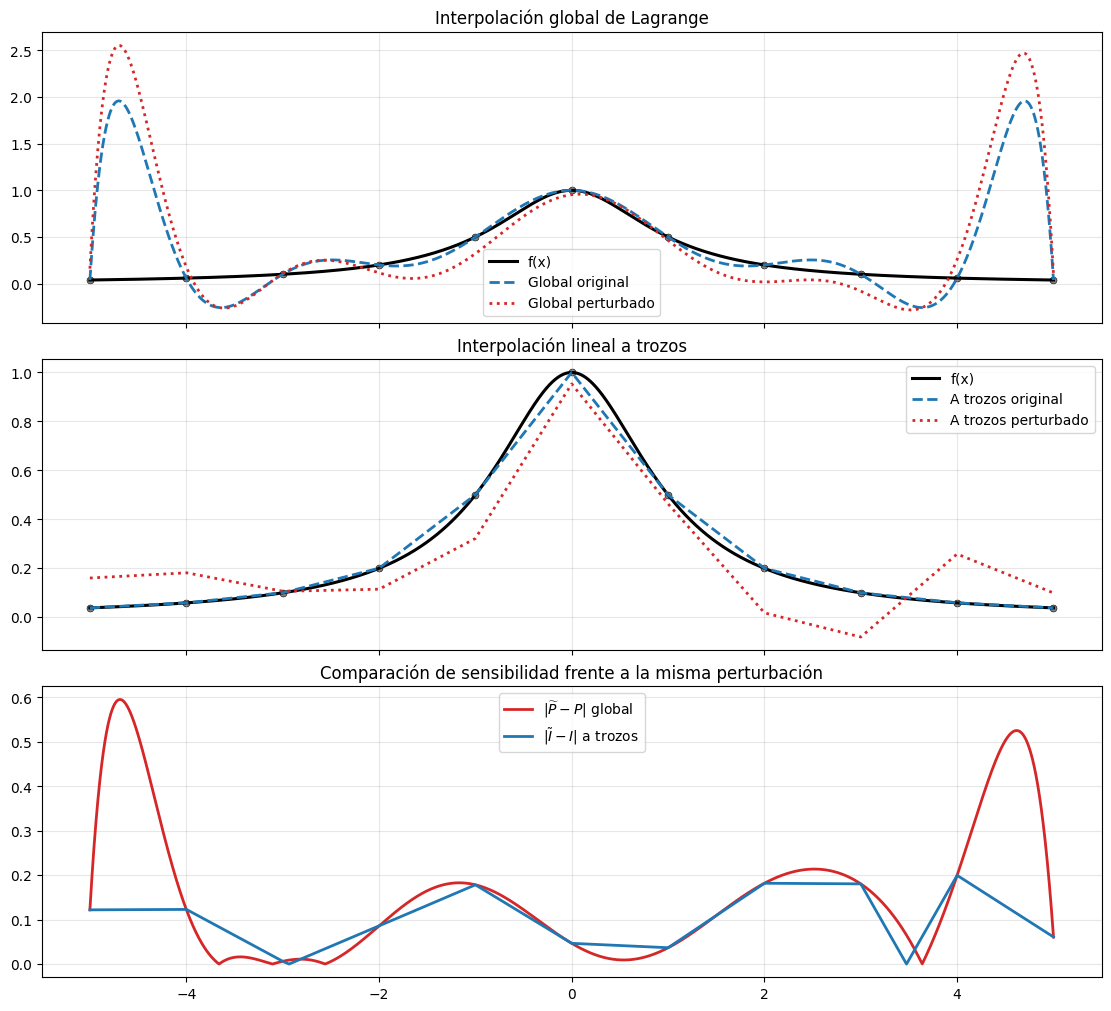

In [ ]:
a, b = -5, 5
alpha = 1.0
n = 11

print("===== Misma perturbación en un solo nodo =====")
comparar_sensibilidad_global_trozos(
    a, b, n,
    alpha=alpha,
    eps=0.2,
    modo="uno",
    seed=0
)

print("\n===== Perturbaciones distintas en todos los nodos =====")
comparar_sensibilidad_global_trozos(
    a, b, n,
    alpha=alpha,
    eps=0.2,
    modo="distinto",
    seed=5
)

# Conclusiones

A partir de todas las pruebas numéricas realizadas, se concluye lo siguiente:

### 1. Sobre el fenómeno de Runge

Para la función

$$
f(x)=\frac{1}{1+x^2},
$$

la interpolación global de Lagrange con nodos equidistantes presenta oscilaciones grandes cerca de los extremos del intervalo cuando aumenta el número de nodos.  
Por tanto, en este ejemplo se valida el **fenómeno de no convergencia uniforme** de la interpolación global con nodos equidistantes.

### 2. Acerca de la inestabilidad

Si los valores en los nodos sufren pequeñas perturbaciones, el polinomio interpolante global puede modificarse de manera considerable.
Este comportamiento pone de manifiesto la **inestabilidad** inherente al procedimiento de interpolación global.

### 3. Sobre la interpolación por partes

La interpolación lineal por tramos evita construir un único polinomio global de grado elevado.
En su lugar, se emplean aproximaciones locales en cada subintervalo, lo que proporciona dos beneficios principales:

- Disminuye o incluso elimina las oscilaciones extremas asociadas al fenómeno de Runge
- Limita la propagación de perturbaciones, haciendo que su efecto sea más localizado y controlado.

Por esta razón, la interpolación por partes puede entenderse como una alternativa natural frente a los inconvenientes descritos en los puntos anteriores.

---

## Conclusión

Los dos primeros apartados evidencian que la interpolación polinómica global con nodos equidistantes puede presentar dificultades tanto en términos de **precisión de aproximación** como de **estabilidad numérica**.
En cambio, el tercer apartado muestra que la **interpolación por tramos** mitiga en gran medida estos problemas al sustituir una aproximación global de grado alto por aproximaciones locales de menor grado.

## Referencias y páginas usadas

[1] T. Sauer, *Numerical Analysis*, 3rd ed., Pearson, 2018.  
    - Sección 3.2.3: *Runge phenomenon*, p. 162.  
    - Sección 3.3: *Chebyshev Interpolation*, pp. 164--169.  
    - Allí se discuten el fenómeno de Runge, la elección de nodos de Chebyshev y por qué esta distribución mejora el comportamiento de la interpolación frente a los nodos equidistantes.

[2] T. A. Driscoll y R. J. Braun, *Fundamentals of Numerical Computation*, SIAM, 2017.  
    - Capítulo 5: *Piecewise interpolation and calculus*, pp. 175--225.  
    - En particular, Sección 5.2: *Piecewise linear interpolation*.  
    - Allí aparecen la definición del interpolante lineal a trozos, el Teorema 5.2.1 sobre condicionamiento y el Teorema 5.2.2 sobre convergencia de orden \(O(h^2)\).

